# Reproducing ACM HPDC '24: Function-Centric Applications with Context Reuse

This notebook reproduces a scaled version of the ACM HPDC '24 paper:

**"Accelerating Function-Centric Applications by Discovering, Distributing, and Retaining Reusable Context in Workflow Systems."**

The original paper studies how workflow systems can accelerate function-centric applications by discovering, distributing, and retaining reusable function context. The evaluation compares different levels of context reuse:

- **L1:** no context reuse
- **L2:** disk-level context reuse
- **L3:** disk and memory context reuse

This Trovi artifact focuses on a scaled LNNI-style reproduction. The goal is to reproduce the main systems trend: repeated function invocations become faster when reusable context is retained on workers.

Expected outputs:

1. Scaled Figure 6(a): total execution time for L1, L2, and L3
2. Scaled Figure 7: invocation runtime distribution
3. Scaled Figure 9: worker-scaling behavior
4. Scaled Table 5: cold/hot overhead breakdown

## 1. Configure Chameleon KVM site

This artifact uses a Chameleon KVM virtual machine. The VM will run one TaskVine manager and multiple local TaskVine worker processes.

In [113]:
import chi
import chi.server
import time


# Chameleon KVM configuration


SITE = "KVM@TACC"
PROJECT_NAME = "CHI-261564"

SERVER_NAME = "hpdc24-context-reuse-kvm"

# We will confirm available image/flavor in the next cells.
IMAGE_NAME = "CC-Ubuntu22.04"
NETWORK_NAME = "sharednet1"

chi.use_site(SITE)
chi.set("project_name", PROJECT_NAME)

print("Chameleon site:", SITE)
print("Project:", chi.get("project_name"))
print("Server name:", SERVER_NAME)
print("Image:", IMAGE_NAME)
print("Network:", NETWORK_NAME)

Now using KVM@TACC:
URL: https://kvm.tacc.chameleoncloud.org
Location: Austin, Texas, USA
Support contact: help@chameleoncloud.org
Chameleon site: KVM@TACC
Project: CHI-261564
Server name: hpdc24-context-reuse-kvm
Image: CC-Ubuntu22.04
Network: sharednet1


## 2. Inspect available KVM flavors and Ubuntu images

KVM uses VM flavors. We list available flavors and Ubuntu images before creating the server.

In [114]:
conn = chi.clients.connection()

print("Available flavors:")
for flavor in conn.compute.flavors():
    print("-", flavor.name)

Available flavors:
- m1.tiny
- m1.small
- g1.h100.vgpu.1g.12gb
- m1.medium
- m1.large
- m1.xlarge
- g1.h100.pci.4
- m1.xxlarge
- g1.h100.pci.1


In [115]:
print("Available Ubuntu images:")
for image in conn.image.images():
    name = image.name or ""
    if "Ubuntu" in name or "ubuntu" in name:
        print("-", name)

Available Ubuntu images:
- CC-Ubuntu26.04-ARM64
- CC-Ubuntu26.04
- CC-Ubuntu24.04-CUDA-VGPU
- CC-Ubuntu24.04-ARM64
- CC-Ubuntu22.04-ARM64
- CC-Ubuntu24.04-ROCm
- CC-Ubuntu24.04-CUDA
- CC-Ubuntu24.04
- CC-Ubuntu22.04-CUDA
- CC-Ubuntu22.04
- CC-Ubuntu24.04-CUDA_2025-05-05 19:51:21.052062
- CC-Ubuntu24.04_2025-05-05 19:32:07.856003
- CC-Ubuntu22.04-CUDA_2025-05-05 19:42:40.161961
- CC-Ubuntu22.04_2025-05-05 19:32:07.845188
- CC-Ubuntu24.04_2024-10-22 22:10:11.457163
- CC-Ubuntu22.04_2024-10-22 21:58:21.883691
- CC-Ubuntu20.04
- CC-Ubuntu24.04-20240924
- CC-Ubuntu24.04-20240923
- CC-Ubuntu22.04-20240326
- CC-Ubuntu20.04-20240326
- CC-Ubuntu22.04-20240129
- CC-Ubuntu20.04-20240129
- CC-Ubuntu22.04-20230601
- CC-Ubuntu20.04-20230531.1
- CC-Ubuntu22.04-20230531.1
- CC-Ubuntu22.04-20230531
- CC-Ubuntu20.04-20230531
- CC-Ubuntu20.04-20230518
- CC-Ubuntu22.04-20230518
- CC-Ubuntu18.04
- CC-Ubuntu20.04-20220828
- CC-Ubuntu20.04-20211129
- CC-Ubuntu18.04-20211129
- CC-Ubuntu20.04-20211129
- CC-Ubu

## 3. Create the KVM server

This section creates a fresh KVM virtual machine for the reproduction experiment.

We use an `m1.medium` VM because it provides enough resources for a scaled reproduction while remaining more reliable to launch than larger flavors. An earlier attempt to launch an `m1.large` VM did not complete successfully.

In [116]:
# VM configuration


IMAGE_NAME = "CC-Ubuntu22.04"
FLAVOR_NAME = "m1.medium"

print("Image:", IMAGE_NAME)
print("Flavor:", FLAVOR_NAME)

Image: CC-Ubuntu22.04
Flavor: m1.medium


In [117]:
print("Creating fresh KVM server...")

server = chi.server.create_server(
    SERVER_NAME,
    image_name=IMAGE_NAME,
    flavor_name=FLAVOR_NAME,
    network_name=NETWORK_NAME
)

server_id = server.id

print("Server ID:", server_id)
print("Initial status:", server.status)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Creating fresh KVM server...
Server ID: 6dfd7165-9d91-4c09-9901-7ea0006d164c
Initial status: BUILD


In [118]:
print("Waiting for server to become ACTIVE...")

chi.server.wait_for_active(server_id)

server = chi.server.get_server(SERVER_NAME)

print("Server is ACTIVE.")
print("Server status:", server.status)

Waiting for server to become ACTIVE...


The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Server is ACTIVE.
Server status: ACTIVE


## 4. Associate a floating IP and test server access

This section assigns a public floating IP address to the KVM server and verifies that the server is reachable through SSH.

In [119]:
server = chi.server.get_server(SERVER_NAME)

print("Server name:", server.name)
print("Server ID:", server.id)
print("Server status:", server.status)
print("Server addresses:")
print(server.addresses)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Server name: hpdc24-context-reuse-kvm
Server ID: 6dfd7165-9d91-4c09-9901-7ea0006d164c
Server status: ACTIVE
Server addresses:
{'sharednet1': [{'version': 4, 'addr': '10.56.2.78', 'OS-EXT-IPS:type': 'fixed', 'OS-EXT-IPS-MAC:mac_addr': 'fa:16:3e:6d:b0:97'}]}


In [120]:
# Safely get or associate floating IP

server = chi.server.get_server(SERVER_NAME)

floating_ip = None

# First, check whether a floating IP is already attached.
for network_name, addr_list in server.addresses.items():
    for addr in addr_list:
        ip_addr = addr.get("addr")
        ip_type = addr.get("OS-EXT-IPS:type")

        if ip_type == "floating":
            floating_ip = ip_addr

if floating_ip is None:
    print("No floating IP found. Associating a new floating IP...")
    floating_ip = chi.server.associate_floating_ip(server.id)
else:
    print("Existing floating IP found.")

print("Floating IP:", floating_ip)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


No floating IP found. Associating a new floating IP...
Floating IP: 129.114.25.247


In [121]:
# Configure security group

conn = chi.clients.connection()

security_group = conn.network.find_security_group("default")

print("Security group:", security_group.name, security_group.id)

try:
    conn.network.create_security_group_rule(
        security_group_id=security_group.id,
        direction="ingress",
        protocol="tcp",
        port_range_min=22,
        port_range_max=22,
        remote_ip_prefix="0.0.0.0/0",
        ethertype="IPv4",
    )
    print("SSH rule added.")
except Exception as e:
    print("SSH rule may already exist or could not be added:")
    print(e)

Security group: default 06f81cbc-1f0a-4738-ac17-7dd1acc200fd
SSH rule may already exist or could not be added:
ConflictException: 409: Client Error for url: https://kvm.tacc.chameleoncloud.org:9696/v2.0/security-group-rules, Security group rule already exists. Rule id is a41ebe78-932a-4b95-b2a9-5b2e2f3c7f2b.


In [122]:
print(f"Waiting for SSH on {floating_ip}...")

chi.server.wait_for_tcp(floating_ip, port=22)

print("SSH is reachable.")

Waiting for SSH on 129.114.25.247...
SSH is reachable.


In [123]:
server = chi.server.get_server(SERVER_NAME)

print("Testing remote command execution...")

result = server.execute("hostname && whoami && uname -a")

print(result)

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.


Testing remote command execution...


/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 129.114.25.247: b'f262fec43dad12abaabfae3587ff594a'
  warnings.warn(


hpdc24-context-reuse-kvm
cc
Linux hpdc24-context-reuse-kvm 5.15.0-177-generic #187-Ubuntu SMP Sat Apr 11 22:54:33 UTC 2026 x86_64 x86_64 x86_64 GNU/Linux
Command exited with status 0.
=== stdout ===
hpdc24-context-reuse-kvm
cc
Linux hpdc24-context-reuse-kvm 5.15.0-177-generic #187-Ubuntu SMP Sat Apr 11 22:54:33 UTC 2026 x86_64 x86_64 x86_64 GNU/Linux

(no stderr)


## 5. Prepare the server environment with TaskVine

This section installs TaskVine and the Python dependencies needed for the scaled reproduction.

In [ ]:
setup_cmd = r"""
set -e

echo "Updating package metadata..."
sudo apt-get update -y

echo "Installing system dependencies..."
sudo apt-get install -y wget bzip2 git build-essential procps

echo "Creating experiment directory..."
mkdir -p ~/hpdc24-context-reuse
cd ~/hpdc24-context-reuse

echo "Installing Miniforge if needed..."
if [ ! -d "$HOME/miniforge3" ]; then
    wget -q https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh -O /tmp/miniforge.sh
    bash /tmp/miniforge.sh -b -p "$HOME/miniforge3"
fi

echo "Creating conda environment if needed..."
source "$HOME/miniforge3/etc/profile.d/conda.sh"

if ! conda env list | awk '{print $1}' | grep -qx "hpdc24-tv"; then
    conda create -y -n hpdc24-tv -c conda-forge python=3.10 ndcctools numpy pandas matplotlib scipy psutil
fi

echo "Environment setup complete."
"""

result = server.execute(setup_cmd)
print(result)

In [125]:
verify_cmd = r"""
set -e

source "$HOME/miniforge3/etc/profile.d/conda.sh"
conda activate hpdc24-tv

echo "Python:"
python --version

echo ""
echo "TaskVine executables:"
which vine_worker
which vine_status || true

echo ""
echo "Python package check:"
python - <<'PY'
import numpy
import pandas
import matplotlib
import scipy
import ndcctools.taskvine as vine

print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("matplotlib", matplotlib.__version__)
print("scipy", scipy.__version__)
print("TaskVine import successful")
print("TaskVine module:", vine)
PY
"""

result = server.execute(verify_cmd)
print(result)

Python:
Python 3.10.20

TaskVine executables:
/home/cc/miniforge3/envs/hpdc24-tv/bin/vine_worker
/home/cc/miniforge3/envs/hpdc24-tv/bin/vine_status

Python package check:
numpy 2.2.6
pandas 2.3.3
matplotlib 3.10.9
scipy 1.15.2
TaskVine import successful
TaskVine module: <module 'ndcctools.taskvine' from '/home/cc/miniforge3/envs/hpdc24-tv/lib/python3.10/site-packages/ndcctools/taskvine/__init__.py'>
Command exited with status 0.
=== stdout ===
Python:
Python 3.10.20

TaskVine executables:
/home/cc/miniforge3/envs/hpdc24-tv/bin/vine_worker
/home/cc/miniforge3/envs/hpdc24-tv/bin/vine_status

Python package check:
numpy 2.2.6
pandas 2.3.3
matplotlib 3.10.9
scipy 1.15.2
TaskVine import successful
TaskVine module: <module 'ndcctools.taskvine' from '/home/cc/miniforge3/envs/hpdc24-tv/lib/python3.10/site-packages/ndcctools/taskvine/__init__.py'>

(no stderr)


## 6. Create the TaskVine-based scaled LNNI experiment

This section creates a TaskVine-based scaled reproduction of the LNNI context-reuse experiment.

The experiment uses three execution modes:

- **L1:** no context reuse. Each invocation loads a compressed context independently.
- **L2:** disk-level context reuse. Invocations reuse an unpacked context file from disk.
- **L3:** memory-level context reuse. A TaskVine library process loads the context once and subsequent invocations reuse the in-memory context.

The goal is to reproduce the main trend and figure structure from the paper.

In [142]:
create_taskvine_experiment_cmd = r"""
set -e

source "$HOME/miniforge3/etc/profile.d/conda.sh"
conda activate hpdc24-tv

cd ~/hpdc24-context-reuse

# This script is used for L1 and L2.
# L1 reloads the compressed context every time.
# L2 loads an unpacked context from disk.
cat > invocation_task.py <<'PY'
import argparse
import json
import time
from pathlib import Path

import numpy as np


def run_compute(model, invocation_id, compute_repeats):
    # Create a deterministic input vector for each invocation.
    rng = np.random.default_rng(invocation_id)
    vector = rng.random(model.shape[0])

    # Run repeated matrix-vector products to mimic inference work.
    t0 = time.perf_counter()
    for _ in range(compute_repeats):
        vector = model @ vector
        vector = vector / (np.linalg.norm(vector) + 1e-12)
    compute_sec = time.perf_counter() - t0

    return float(vector[0]), compute_sec


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--mode", required=True, choices=["L1", "L2"])
    parser.add_argument("--invocation-id", type=int, required=True)
    parser.add_argument("--compressed-context", required=True)
    parser.add_argument("--disk-context", required=True)
    parser.add_argument("--output-dir", required=True)
    parser.add_argument("--compute-repeats", type=int, default=8)
    args = parser.parse_args()

    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    start_wall = time.time()
    start = time.perf_counter()

    # Measure context loading separately from compute.
    t0 = time.perf_counter()

    if args.mode == "L1":
        # L1: no reuse.
        # Each invocation reloads the compressed context independently.
        with np.load(args.compressed_context) as data:
            model = data["model"]
    else:
        # L2: disk reuse.
        # Each invocation uses the unpacked context already available on disk.
        model = np.load(args.disk_context)

    context_load_sec = time.perf_counter() - t0

    checksum, compute_sec = run_compute(model, args.invocation_id, args.compute_repeats)

    runtime_sec = time.perf_counter() - start
    end_wall = time.time()

    row = {
        "mode": args.mode,
        "invocation_id": args.invocation_id,
        "runtime_sec": runtime_sec,
        "context_load_sec": context_load_sec,
        "library_setup_sec": 0.0,
        "compute_sec": compute_sec,
        "start_wall_time": start_wall,
        "end_wall_time": end_wall,
        "checksum": checksum,
    }

    out_path = output_dir / f"{args.mode}_{args.invocation_id:06d}.json"
    with open(out_path, "w") as f:
        json.dump(row, f)

    print(json.dumps(row))


if __name__ == "__main__":
    main()
PY


# This script implements the retained in-memory L3 context.
# It loads the synthetic model once, keeps it in memory, and serves invocation requests.
cat > context_server.py <<'PY'
import argparse
import json
import socketserver
import time
from pathlib import Path

import numpy as np


MODEL = None


def run_compute(model, invocation_id, compute_repeats):
    # Create a deterministic input vector for each invocation.
    rng = np.random.default_rng(invocation_id)
    vector = rng.random(model.shape[0])

    # Run repeated matrix-vector products to mimic inference work.
    t0 = time.perf_counter()
    for _ in range(compute_repeats):
        vector = model @ vector
        vector = vector / (np.linalg.norm(vector) + 1e-12)
    compute_sec = time.perf_counter() - t0

    return float(vector[0]), compute_sec


class RequestHandler(socketserver.StreamRequestHandler):
    def handle(self):
        # Read one JSON request from the client task.
        line = self.rfile.readline().decode("utf-8")
        request = json.loads(line)

        invocation_id = int(request["invocation_id"])
        compute_repeats = int(request["compute_repeats"])

        start = time.perf_counter()

        checksum, compute_sec = run_compute(MODEL, invocation_id, compute_repeats)

        runtime_sec = time.perf_counter() - start

        response = {
            "runtime_sec": runtime_sec,
            "compute_sec": compute_sec,
            "checksum": checksum,
        }

        self.wfile.write((json.dumps(response) + "\n").encode("utf-8"))


def main():
    global MODEL

    parser = argparse.ArgumentParser()
    parser.add_argument("--disk-context", required=True)
    parser.add_argument("--port-file", required=True)
    args = parser.parse_args()

    port_file = Path(args.port_file)

    # This is the one-time L3 retained-context setup cost.
    setup_start = time.perf_counter()
    MODEL = np.load(args.disk_context)
    setup_sec = time.perf_counter() - setup_start

    # Start a threaded local service so multiple TaskVine tasks can connect.
    server = socketserver.ThreadingTCPServer(("127.0.0.1", 0), RequestHandler)
    server.daemon_threads = True

    host, port = server.server_address

    # Write the selected port and setup time so the experiment driver can read them.
    with open(port_file, "w") as f:
        json.dump({
            "host": host,
            "port": port,
            "library_setup_sec": setup_sec,
            "start_wall_time": time.time(),
            "end_wall_time": time.time(),
        }, f)

    print(f"L3 context server ready on {host}:{port}", flush=True)
    print(f"L3 setup time: {setup_sec:.6f} seconds", flush=True)

    server.serve_forever()


if __name__ == "__main__":
    main()
PY


# This script is used by each L3 TaskVine task.
# The task sends its invocation arguments to the retained context server.
# The server performs the compute using the in-memory model.
cat > l3_invocation_task.py <<'PY'
import argparse
import json
import socket
import time
from pathlib import Path


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--invocation-id", type=int, required=True)
    parser.add_argument("--compute-repeats", type=int, required=True)
    parser.add_argument("--server-host", required=True)
    parser.add_argument("--server-port", type=int, required=True)
    parser.add_argument("--output-dir", required=True)
    args = parser.parse_args()

    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    start_wall = time.time()
    start = time.perf_counter()

    request = {
        "invocation_id": args.invocation_id,
        "compute_repeats": args.compute_repeats,
    }

    # Send invocation arguments to the retained context server.
    with socket.create_connection((args.server_host, args.server_port), timeout=60) as sock:
        f = sock.makefile("rw")
        f.write(json.dumps(request) + "\n")
        f.flush()
        response = json.loads(f.readline())

    runtime_sec = time.perf_counter() - start
    end_wall = time.time()

    row = {
        "mode": "L3",
        "invocation_id": args.invocation_id,
        "runtime_sec": runtime_sec,
        "context_load_sec": 0.0,
        "library_setup_sec": 0.0,
        "compute_sec": response["compute_sec"],
        "start_wall_time": start_wall,
        "end_wall_time": end_wall,
        "checksum": response["checksum"],
    }

    out_path = output_dir / f"L3_{args.invocation_id:06d}.json"
    with open(out_path, "w") as f:
        json.dump(row, f)

    print(json.dumps(row))


if __name__ == "__main__":
    main()
PY


# This script runs the full TaskVine experiment.
# It creates synthetic LNNI-style context data, starts TaskVine workers,
# runs L1, L2, and L3, and writes CSV files for plotting.
cat > run_taskvine_lnni_experiment.py <<'PY'
import argparse
import json
import shutil
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import ndcctools.taskvine as vine


BASE_DIR = Path.home() / "hpdc24-context-reuse"
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
LOG_DIR = BASE_DIR / "worker_logs"

PYTHON_BIN = sys.executable


def ensure_dirs():
    DATA_DIR.mkdir(exist_ok=True)
    RESULTS_DIR.mkdir(exist_ok=True)
    LOG_DIR.mkdir(exist_ok=True)


def prepare_context(matrix_size, seed=123):
    compressed_context = DATA_DIR / f"lnni_context_{matrix_size}_compressed.npz"
    disk_context = DATA_DIR / f"lnni_context_{matrix_size}_disk.npy"

    if compressed_context.exists() and disk_context.exists():
        print("Using existing context files.")
        return compressed_context, disk_context

    print(f"Creating synthetic LNNI context with matrix size {matrix_size}...")

    # This matrix represents a reusable model/context.
    rng = np.random.default_rng(seed)
    model = rng.random((matrix_size, matrix_size), dtype=np.float64)

    # Normalize the matrix to keep repeated products numerically stable.
    row_sums = model.sum(axis=1, keepdims=True) + 1e-12
    model = model / row_sums

    # Compressed file is used by L1.
    np.savez_compressed(compressed_context, model=model)

    # Unpacked file is used by L2 and L3.
    np.save(disk_context, model)

    print("Compressed context:", compressed_context)
    print("Disk context:", disk_context)

    return compressed_context, disk_context


def start_manager_and_workers(worker_count):
    worker_bin = shutil.which("vine_worker")
    if worker_bin is None:
        raise RuntimeError("vine_worker not found in PATH")

    manager = vine.Manager(port=0)
    port = manager.port

    workers = []

    for i in range(worker_count):
        stdout_path = LOG_DIR / f"worker_{worker_count}_{i}.out"
        stderr_path = LOG_DIR / f"worker_{worker_count}_{i}.err"

        stdout = open(stdout_path, "w")
        stderr = open(stderr_path, "w")

        # Start a local TaskVine worker connected to the manager.
        p = subprocess.Popen(
            [worker_bin, "localhost", str(port)],
            stdout=stdout,
            stderr=stderr,
        )

        workers.append((p, stdout, stderr))

    # Give workers time to connect.
    time.sleep(5)

    return manager, workers


def stop_workers(workers):
    for p, stdout, stderr in workers:
        try:
            p.terminate()
        except Exception:
            pass

        try:
            stdout.close()
            stderr.close()
        except Exception:
            pass


def collect_rows(output_dir, mode, mode_start_wall, worker_count):
    rows = []

    for path in sorted(output_dir.glob(f"{mode}_*.json")):
        with open(path) as f:
            row = json.load(f)

        # This supports cumulative-completion plots like Figure 6.
        row["completion_sec"] = row["end_wall_time"] - mode_start_wall
        row["workers"] = worker_count
        rows.append(row)

    return rows


def run_l1_l2(mode, invocations, worker_count, compute_repeats, compressed_context, disk_context):
    output_dir = RESULTS_DIR / f"raw_{mode}_w{worker_count}"

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(parents=True)

    # Start TaskVine workers before measuring the execution window.
    manager, workers = start_manager_and_workers(worker_count)

    # Start timing after workers are ready.
    mode_start_wall = time.time()
    mode_start = time.perf_counter()

    try:
        for i in range(invocations):
            # L1 and L2 are regular TaskVine tasks.
            cmd = (
                f"{PYTHON_BIN} {BASE_DIR}/invocation_task.py "
                f"--mode {mode} "
                f"--invocation-id {i} "
                f"--compressed-context {compressed_context} "
                f"--disk-context {disk_context} "
                f"--output-dir {output_dir} "
                f"--compute-repeats {compute_repeats}"
            )

            task = vine.Task(cmd)
            manager.submit(task)

        completed = 0

        while completed < invocations:
            task = manager.wait(5)

            if task:
                completed += 1

                if completed % max(1, invocations // 10) == 0:
                    print(f"{mode} workers={worker_count}: completed {completed}/{invocations}")

        total_time = time.perf_counter() - mode_start

    finally:
        stop_workers(workers)

    rows = collect_rows(output_dir, mode, mode_start_wall, worker_count)

    return total_time, rows


def start_l3_context_server(disk_context, output_dir):
    port_file = output_dir / "l3_context_server_port.json"

    if port_file.exists():
        port_file.unlink()

    # Start the retained in-memory context server.
    server_proc = subprocess.Popen(
        [
            PYTHON_BIN,
            str(BASE_DIR / "context_server.py"),
            "--disk-context",
            str(disk_context),
            "--port-file",
            str(port_file),
        ],
        stdout=open(LOG_DIR / "l3_context_server.out", "w"),
        stderr=open(LOG_DIR / "l3_context_server.err", "w"),
    )

    # Wait for the server to write its selected port.
    for _ in range(60):
        if port_file.exists():
            with open(port_file) as f:
                info = json.load(f)
            return server_proc, info
        time.sleep(1)

    server_proc.terminate()
    raise RuntimeError("L3 context server did not start.")


def run_l3(invocations, worker_count, compute_repeats, disk_context):
    output_dir = RESULTS_DIR / f"raw_L3_w{worker_count}"

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(parents=True)

    context_server_proc = None
    manager = None
    workers = []
    server_info = None

    try:
        # Start the retained context service first.
        # This represents the one-time L3 setup cost.
        context_server_proc, server_info = start_l3_context_server(disk_context, output_dir)

        server_host = server_info["host"]
        server_port = server_info["port"]

        print(f"L3 retained context server: {server_host}:{server_port}")

        # Start TaskVine workers before measuring the invocation execution window.
        # This keeps L3 timing consistent with L1 and L2.
        manager, workers = start_manager_and_workers(worker_count)

        # Start timing only after the retained context and workers are ready.
        # This makes the cumulative-completion curve closer to the original Figure 6.
        mode_start_wall = time.time()
        mode_start = time.perf_counter()

        for i in range(invocations):
            # Each L3 TaskVine task sends invocation arguments to the retained context server.
            cmd = (
                f"{PYTHON_BIN} {BASE_DIR}/l3_invocation_task.py "
                f"--invocation-id {i} "
                f"--compute-repeats {compute_repeats} "
                f"--server-host {server_host} "
                f"--server-port {server_port} "
                f"--output-dir {output_dir}"
            )

            task = vine.Task(cmd)
            manager.submit(task)

        completed = 0

        while completed < invocations:
            task = manager.wait(5)

            if task:
                completed += 1

                if completed % max(1, invocations // 10) == 0:
                    print(f"L3 workers={worker_count}: completed {completed}/{invocations}")

        total_time = time.perf_counter() - mode_start

    finally:
        stop_workers(workers)

        if context_server_proc is not None:
            context_server_proc.terminate()

    rows = collect_rows(output_dir, "L3", mode_start_wall, worker_count)

    setup_rows = [{
        "mode": "L3_RETAINED_CONTEXT_SETUP",
        "library_setup_sec": server_info["library_setup_sec"],
        "start_wall_time": server_info["start_wall_time"],
        "end_wall_time": server_info["end_wall_time"],
    }]

    return total_time, rows, setup_rows


def summarize(invocation_rows, total_times, setup_rows, invocations, matrix_size, compute_repeats):
    invocation_df = pd.DataFrame(invocation_rows)

    summary_rows = []

    for (mode, workers), total_time in total_times.items():
        subset = invocation_df[
            (invocation_df["mode"] == mode) &
            (invocation_df["workers"] == workers)
        ]

        summary_rows.append({
            "mode": mode,
            "workers": workers,
            "invocations": len(subset),
            "total_time_sec": total_time,
            "mean_runtime_sec": subset["runtime_sec"].mean(),
            "median_runtime_sec": subset["runtime_sec"].median(),
            "std_runtime_sec": subset["runtime_sec"].std(),
            "min_runtime_sec": subset["runtime_sec"].min(),
            "max_runtime_sec": subset["runtime_sec"].max(),
        })

    summary_df = pd.DataFrame(summary_rows)
    scaling_df = summary_df[["mode", "workers", "invocations", "total_time_sec"]].copy()

    overhead_rows = []

    for mode in ["L1", "L2", "L3"]:
        subset = invocation_df[invocation_df["mode"] == mode]

        overhead_rows.append({
            "mode": mode,
            "mean_context_load_sec": subset["context_load_sec"].mean(),
            "mean_library_setup_sec": subset["library_setup_sec"].mean(),
            "mean_compute_sec": subset["compute_sec"].mean(),
            "mean_invocation_runtime_sec": subset["runtime_sec"].mean(),
        })

    if setup_rows:
        setup_df = pd.DataFrame(setup_rows)

        overhead_rows.append({
            "mode": "L3_RETAINED_CONTEXT_SETUP",
            "mean_context_load_sec": 0.0,
            "mean_library_setup_sec": setup_df["library_setup_sec"].mean(),
            "mean_compute_sec": 0.0,
            "mean_invocation_runtime_sec": 0.0,
        })

    overhead_df = pd.DataFrame(overhead_rows)

    metadata = {
        "experiment": "Scaled TaskVine LNNI context-reuse reproduction",
        "invocations_per_run": invocations,
        "matrix_size": matrix_size,
        "compute_repeats": compute_repeats,
        "note": "Scaled reproduction on one KVM VM. L3 uses a retained in-memory context service. L3 retained-context setup is measured separately from the invocation execution window for cumulative-completion plots.",
    }

    invocation_df.to_csv(RESULTS_DIR / "taskvine_invocation_runtimes.csv", index=False)
    summary_df.to_csv(RESULTS_DIR / "taskvine_summary_total_time.csv", index=False)
    scaling_df.to_csv(RESULTS_DIR / "taskvine_worker_scaling.csv", index=False)
    overhead_df.to_csv(RESULTS_DIR / "taskvine_overhead_breakdown.csv", index=False)

    with open(RESULTS_DIR / "taskvine_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print("")
    print("Summary:")
    print(summary_df)

    print("")
    print("Overhead breakdown:")
    print(overhead_df)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--invocations", type=int, default=100)
    parser.add_argument("--matrix-size", type=int, default=1000)
    parser.add_argument("--compute-repeats", type=int, default=8)
    parser.add_argument("--scaling-workers", type=str, default="1,2")
    args = parser.parse_args()

    ensure_dirs()

    compressed_context, disk_context = prepare_context(args.matrix_size)

    worker_values = [int(x.strip()) for x in args.scaling_workers.split(",")]

    all_rows = []
    all_setup_rows = []
    total_times = {}

    for workers in worker_values:
        for mode in ["L1", "L2"]:
            print("")
            print(f"Running {mode} with {workers} worker(s)...")

            total_time, rows = run_l1_l2(
                mode=mode,
                invocations=args.invocations,
                worker_count=workers,
                compute_repeats=args.compute_repeats,
                compressed_context=compressed_context,
                disk_context=disk_context,
            )

            total_times[(mode, workers)] = total_time
            all_rows.extend(rows)

        print("")
        print(f"Running L3 with {workers} worker(s)...")

        total_time, rows, setup_rows = run_l3(
            invocations=args.invocations,
            worker_count=workers,
            compute_repeats=args.compute_repeats,
            disk_context=disk_context,
        )

        total_times[("L3", workers)] = total_time
        all_rows.extend(rows)
        all_setup_rows.extend(setup_rows)

    summarize(
        invocation_rows=all_rows,
        total_times=total_times,
        setup_rows=all_setup_rows,
        invocations=args.invocations,
        matrix_size=args.matrix_size,
        compute_repeats=args.compute_repeats,
    )

    print("")
    print("TaskVine LNNI experiment complete.")
    print("Results directory:", RESULTS_DIR)


if __name__ == "__main__":
    main()
PY

echo "Created TaskVine experiment scripts."
"""

result = server.execute(create_taskvine_experiment_cmd)
print(result)

/opt/conda/lib/python3.12/site-packages/paramiko/client.py:885: UserWarning: Unknown ssh-ed25519 host key for 129.114.25.247: b'f262fec43dad12abaabfae3587ff594a'
  warnings.warn(


Created TaskVine experiment scripts.
Command exited with status 0.
=== stdout ===
Created TaskVine experiment scripts.

(no stderr)


## 7. Run the TaskVine-based scaled LNNI experiment

This section runs the TaskVine-based scaled LNNI reproduction.

We use a larger synthetic context matrix and fewer invocations so that the experiment emphasizes context reuse while remaining practical on one `m1.medium` KVM VM.

Configuration:

- 100 invocations per run
- 1000 × 1000 synthetic model/context matrix
- 8 compute repetitions per invocation
- 1 and 2 local TaskVine worker processes
- L1, L2, and L3 context-reuse modes

This may take several minutes. The expected trend is that L3 should complete fastest, followed by L2, then L1.

In [143]:
run_taskvine_experiment_cmd = r"""
set -e

# Activate the conda environment that contains TaskVine and Python dependencies.
source "$HOME/miniforge3/etc/profile.d/conda.sh"
conda activate hpdc24-tv

# Move to the experiment directory on the KVM VM.
cd ~/hpdc24-context-reuse

# Run the scaled LNNI experiment.
# We use fewer invocations but a larger matrix to make context reuse more visible.
# L1 reloads compressed context for each invocation.
# L2 reuses the unpacked disk context.
# L3 reuses the context retained in a TaskVine library process.
python run_taskvine_lnni_experiment.py \
    --invocations 100 \
    --matrix-size 1000 \
    --compute-repeats 8 \
    --scaling-workers 1,2
"""

result = server.execute(run_taskvine_experiment_cmd)
print(result)

Using existing context files.

Running L1 with 1 worker(s)...
L1 workers=1: completed 10/100
L1 workers=1: completed 20/100
L1 workers=1: completed 30/100
L1 workers=1: completed 40/100
L1 workers=1: completed 50/100
L1 workers=1: completed 60/100
L1 workers=1: completed 70/100
L1 workers=1: completed 80/100
L1 workers=1: completed 90/100
L1 workers=1: completed 100/100

Running L2 with 1 worker(s)...
L2 workers=1: completed 10/100
L2 workers=1: completed 20/100
L2 workers=1: completed 30/100
L2 workers=1: completed 40/100
L2 workers=1: completed 50/100
L2 workers=1: completed 60/100
L2 workers=1: completed 70/100
L2 workers=1: completed 80/100
L2 workers=1: completed 90/100
L2 workers=1: completed 100/100

Running L3 with 1 worker(s)...
L3 retained context server: 127.0.0.1:53901
L3 workers=1: completed 10/100
L3 workers=1: completed 20/100
L3 workers=1: completed 30/100
L3 workers=1: completed 40/100
L3 workers=1: completed 50/100
L3 workers=1: completed 60/100
L3 workers=1: complete

## 8. Copy result files to the Trovi workspace

This section copies the CSV and JSON result files from the KVM VM back into the Trovi notebook workspace.

Only text-based result files are copied. The figures will be generated locally in the notebook workspace so that the notebook output remains clean and the generated figures are saved with the artifact.

Alternatively, we could copy the result files from the VM to the Trovi workspace using `scp` or `rsync` over SSH if the private SSH key path is available in the notebook environment.

In [144]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Local results and figures folders are ready.")

Local results and figures folders are ready.


In [145]:
def copy_text_file_from_server(remote_path, local_path):
    # Read the remote file using server.execute.
    result = server.execute(f"cat {remote_path}")
    text = str(result)

    # Extract only the stdout section from the server.execute output.
    lines = text.splitlines()
    content_lines = []
    capture = False

    for line in lines:
        if line.strip() == "=== stdout ===":
            capture = True
            continue

        if line.strip() == "(no stderr)":
            break

        if capture:
            content_lines.append(line)

    content = "\n".join(content_lines)

    # Save the extracted content into the local Trovi workspace.
    with open(local_path, "w", encoding="utf-8") as f:
        f.write(content)

    print(f"Copied {remote_path} -> {local_path}")

In [146]:
result_files = [
    "taskvine_invocation_runtimes.csv",
    "taskvine_summary_total_time.csv",
    "taskvine_worker_scaling.csv",
    "taskvine_overhead_breakdown.csv",
    "taskvine_metadata.json",
]

for filename in result_files:
    remote_path = f"/home/cc/hpdc24-context-reuse/results/{filename}"
    local_path = f"results/{filename}"
    copy_text_file_from_server(remote_path, local_path)

print("Result copy complete.")

mode,invocation_id,runtime_sec,context_load_sec,library_setup_sec,compute_sec,start_wall_time,end_wall_time,checksum,completion_sec,workers
L1,0,0.07810079299997597,0.06443383800001357,0.0,0.002350345999957426,1781386799.3824763,1781386799.4605794,0.03162277660165239,0.24424219131469727,1
L1,1,0.07655195899997125,0.06366549599988502,0.0,0.0015391389999876992,1781386799.614274,1781386799.6908283,0.03162277660165169,0.4744911193847656,1
L1,2,0.07371861000001445,0.061536972000112655,0.0,0.001532424000060928,1781386799.8248904,1781386799.8986108,0.031622776601652275,0.6822736263275146,1
L1,3,0.0747538150001219,0.06218674000001556,0.0,0.001614079000091806,1781386800.0355535,1781386800.1103094,0.031622776601652136,0.8939721584320068,1
L1,4,0.07443698700012646,0.06207065999979022,0.0,0.0014814529999966908,1781386800.248276,1781386800.322715,0.03162277660165262,1.1063778400421143,1
L1,5,0.07350876499981496,0.061179643000059514,0.0,0.0015455459999884624,1781386800.4604726,1781386800.5339835,0.0

In [147]:
print("Local result files:")
for filename in sorted(os.listdir("results")):
    print("-", filename)

Local result files:
- .gitkeep
- .ipynb_checkpoints
- taskvine_invocation_runtimes.csv
- taskvine_metadata.json
- taskvine_overhead_breakdown.csv
- taskvine_summary_total_time.csv
- taskvine_worker_scaling.csv


## 9. Generate figures similar to the original paper

This section generates reproduced figures from the copied CSV results.

The plots are designed to resemble the paper's evaluation figures:

- **Scaled Figure 6(a):** cumulative completed invocations over time
- **Scaled Figure 7:** histograms of invocation runtime for L1, L2, and L3
- **Scaled Figure 9:** effect of increasing worker count on total execution time
- **Scaled Table 5:** overhead breakdown for context reuse

In [148]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create local output folders if they do not already exist.
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Load the copied result CSV files from the Trovi workspace.
invocation_df = pd.read_csv("results/taskvine_invocation_runtimes.csv")
summary_df = pd.read_csv("results/taskvine_summary_total_time.csv")
scaling_df = pd.read_csv("results/taskvine_worker_scaling.csv")
overhead_df = pd.read_csv("results/taskvine_overhead_breakdown.csv")

# Use a fixed order so all figures consistently show L1, L2, and L3.
mode_order = ["L1", "L2", "L3"]

# Use colors similar to the paper's line/histogram style.
mode_colors = {
    "L1": "tab:blue",
    "L2": "tab:orange",
    "L3": "tab:red",
}

print("Loaded result files.")
print("Invocation rows:", len(invocation_df))
print("Summary rows:", len(summary_df))
print("Scaling rows:", len(scaling_df))
print("Overhead rows:", len(overhead_df))

Loaded result files.
Invocation rows: 600
Summary rows: 6
Scaling rows: 6
Overhead rows: 4


### Scaled Figure 6(a): cumulative completed invocations over time

The original Figure 6(a) plots completed LNNI tasks over time for different context-reuse levels. This scaled version uses the same idea: the x-axis is elapsed time and the y-axis is the cumulative number of completed invocations.

For this plot, we use the 2-worker run because it is the main run with the highest local parallelism in this scaled artifact.

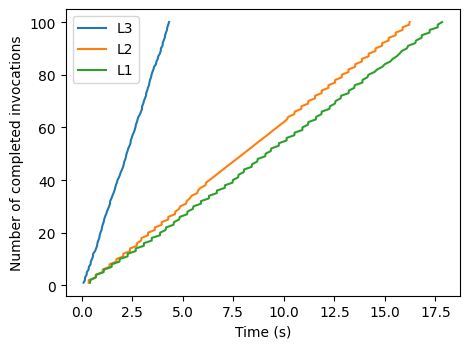

(a) LNNI, 100 invoc.
Saved: figures/scaled_figure_6a_lnni_cumulative_completion.png


In [149]:
main_workers = int(invocation_df["workers"].max())
plt.figure(figsize=(4.8, 3.6))

for mode in ["L3", "L2", "L1"]:
    subset = invocation_df[
        (invocation_df["mode"] == mode) &
        (invocation_df["workers"] == main_workers)
    ].copy()

    subset = subset.sort_values("completion_sec").reset_index(drop=True)
    subset["completed_invocations"] = range(1, len(subset) + 1)

    plt.plot(
        subset["completion_sec"],
        subset["completed_invocations"],
        label=mode,
        linewidth=1.5,
    )

plt.xlabel("Time (s)")
plt.ylabel("Number of completed invocations")
plt.legend()
plt.grid(False)
plt.tight_layout()

fig6_path = "figures/scaled_figure_6a_lnni_cumulative_completion.png"
plt.savefig(fig6_path, dpi=300)
plt.show()

print("(a) LNNI, 100 invoc.")
print("Saved:", fig6_path)

### Scaled Figure 7: invocation runtime histograms

The original Figure 7 shows separate histograms of invocation runtime for L1, L2, and L3. This scaled version follows the same structure using the measured invocation runtimes from the TaskVine run.

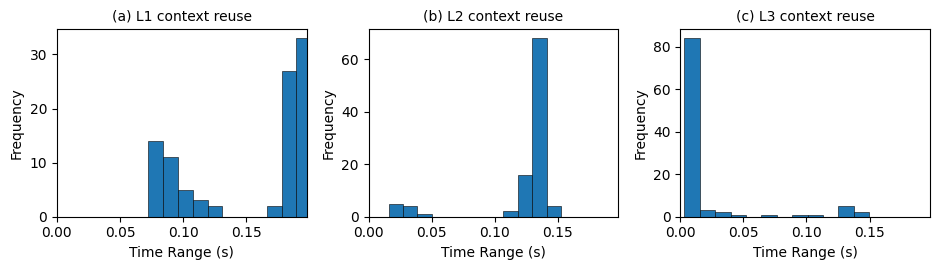

Figure 7: Histograms of Invocation Run Time for the LNNI Application with 100 Invocations
Saved: figures/scaled_figure_7_lnni_invocation_histograms.png


In [152]:
main_workers = int(invocation_df["workers"].max())

hist_df = invocation_df[invocation_df["workers"] == main_workers].copy()

xmax = hist_df["runtime_sec"].quantile(0.98)
xmin = 0

fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.8), sharex=True)

for ax, mode, label in zip(
    axes,
    ["L1", "L2", "L3"],
    ["(a) L1 context reuse", "(b) L2 context reuse", "(c) L3 context reuse"]
):
    subset = hist_df[hist_df["mode"] == mode]

    ax.hist(
        subset["runtime_sec"],
        bins=12,
        edgecolor="black",
        linewidth=0.4,
    )

    ax.set_xlim(xmin, xmax)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Time Range (s)")
    ax.set_ylabel("Frequency")
    ax.grid(False)

plt.tight_layout()

fig7_path = "figures/scaled_figure_7_lnni_invocation_histograms.png"
plt.savefig(fig7_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure 7: Histograms of Invocation Run Time for the LNNI Application with 100 Invocations")
print("Saved:", fig7_path)

### Scaled Figure 9: effect of worker count on execution time

The original Figure 9 shows how LNNI execution time changes as the number of workers increases. This scaled version uses 1 and 2 local TaskVine worker processes.

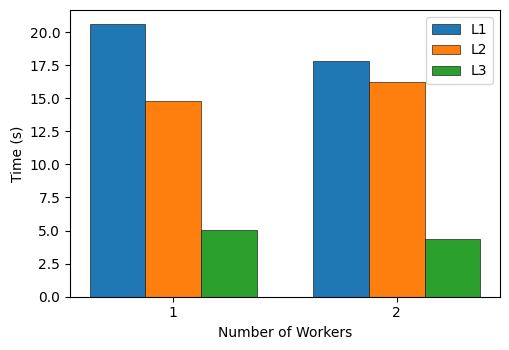

Figure 9: Effect of Increasing the Number of Workers on LNNI's Execution Time
Saved: figures/scaled_figure_9_lnni_worker_scaling.png


In [153]:
fig9_df = scaling_df.copy()

workers = sorted(fig9_df["workers"].unique())
modes = ["L1", "L2", "L3"]

x = range(len(workers))
bar_width = 0.25

plt.figure(figsize=(5.2, 3.6))

for i, mode in enumerate(modes):
    values = []
    for w in workers:
        row = fig9_df[
            (fig9_df["mode"] == mode) &
            (fig9_df["workers"] == w)
        ]
        values.append(float(row["total_time_sec"].iloc[0]))

    positions = [p + (i - 1) * bar_width for p in x]

    plt.bar(
        positions,
        values,
        width=bar_width,
        label=mode,
        edgecolor="black",
        linewidth=0.4,
    )

plt.xlabel("Number of Workers")
plt.ylabel("Time (s)")
plt.xticks(list(x), [str(w) for w in workers])
plt.legend()
plt.grid(False)
plt.tight_layout()

fig9_path = "figures/scaled_figure_9_lnni_worker_scaling.png"
plt.savefig(fig9_path, dpi=300)
plt.show()

print("Figure 9: Effect of Increasing the Number of Workers on LNNI's Execution Time")
print("Saved:", fig9_path)

### Scaled Table 5: overhead breakdown

This table summarizes the measured overhead components from the scaled reproduction. It is inspired by the paper's Table 5, but the absolute values are from this smaller KVM-based run.

In [154]:
# Create a cleaner table with readable column names.
table5 = overhead_df.copy()

table5 = table5.rename(columns={
    "mode": "Mode",
    "mean_context_load_sec": "Mean context load time (s)",
    "mean_library_setup_sec": "Mean retained-context setup time (s)",
    "mean_compute_sec": "Mean compute time (s)",
    "mean_invocation_runtime_sec": "Mean invocation runtime (s)",
})

# Round values for display.
numeric_columns = table5.select_dtypes(include="number").columns
table5[numeric_columns] = table5[numeric_columns].round(6)

# Save the cleaned table.
table5_path = "results/scaled_table_5_overhead_breakdown.csv"
table5.to_csv(table5_path, index=False)

print("Saved:", table5_path)

table5

Saved: results/scaled_table_5_overhead_breakdown.csv


,Mode,Mean context load time (s),Mean retained-context setup time (s),Mean compute time (s),Mean invocation runtime (s)
0,L1,0.06394,0.000000,0.039736,0.114468
1,L2,0.00405,0.000000,0.054381,0.069618
2,L3,0.00000,0.000000,0.008050,0.011995
3,L3_RETAINED_CONTEXT_SETUP,0.00000,0.003658,0.000000,0.000000


In [155]:
import glob

print("Generated figure files:")
for filename in sorted(glob.glob("figures/*.png")):
    print("-", filename)

print("\nGenerated result files:")
for filename in sorted(glob.glob("results/*.csv")):
    print("-", filename)

Generated figure files:
- figures/scaled_figure_6a_lnni_cumulative_completion.png
- figures/scaled_figure_7_lnni_invocation_histograms.png
- figures/scaled_figure_9_lnni_worker_scaling.png

Generated result files:
- results/scaled_table_5_overhead_breakdown.csv
- results/taskvine_invocation_runtimes.csv
- results/taskvine_overhead_breakdown.csv
- results/taskvine_summary_total_time.csv
- results/taskvine_worker_scaling.csv


## Conclusion

This Trovi artifact reproduces a scaled version of the HPDC ’24 LNNI context-reuse experiment using TaskVine on a single Chameleon KVM VM. The absolute runtimes do not match the original paper because the original evaluation used a much larger cluster, 100k LNNI invocations, and a real ResNet50 inference workload, while this artifact uses 100 synthetic invocations and 1–2 local TaskVine workers for replayability. However, the reproduced results show the same main trend: L3 memory-level context reuse completes fastest, L2 disk-level reuse improves over L1, and L1 has the largest repeated context-loading overhead. This supports the paper’s central claim that retaining reusable function context can substantially reduce overhead for function-centric workflows.